# 1. Učitavanje podataka

In [48]:
#Importing packages
import kagglehub
import os
import re
import pandas as pd
import numpy as np
from matplotlib.pylab import plt
import seaborn as sns
from sklearn import metrics
import string
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.svm import LinearSVC
from lightgbm import LGBMClassifier
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D
from sklearn.cluster import KMeans

In [49]:
path = kagglehub.dataset_download("saurabhshahane/fake-news-classification")
print(path)

Using Colab cache for faster access to the 'fake-news-classification' dataset.
/kaggle/input/fake-news-classification


In [50]:
csv_path = os.path.join(path, "WELFake_Dataset.csv")
df = pd.read_csv(csv_path)

In [51]:
df.head(5)

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


# 2. Analiza i priprema podataka


In [52]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72134 non-null  int64 
 1   title       71576 non-null  object
 2   text        72095 non-null  object
 3   label       72134 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.2+ MB


(72134, 4)

In [53]:
df.isnull().sum()

,0
Unnamed: 0,0
title,558
text,39
label,0


In [54]:
df["title"] = df["title"].fillna("")
df["text"] = df["text"].fillna("")

In [55]:
df.shape

(72134, 4)

<Axes: xlabel='label', ylabel='count'>

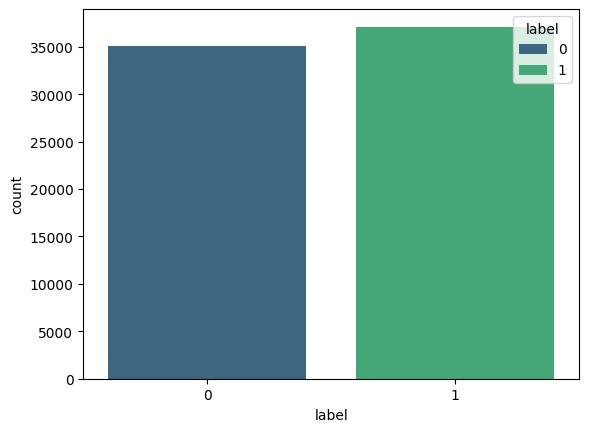

In [56]:
sns.countplot(data=df, x='label', hue='label', palette='viridis')

## Pretprocesiranje

In [57]:
df["content"] = df["title"].astype(str) + " " + df["text"].astype(str)
df["content"] = df["content"].str.strip()

In [58]:
df.drop(["Unnamed: 0"], axis=1, inplace=True)

In [59]:
df[["title", "text", "content"]].head(3)

,title,text,content
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,LAW ENFORCEMENT ON HIGH ALERT Following Threat...
1,,Did they post their votes for Hillary already?,Did they post their votes for Hillary already?
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...


In [60]:
df["content"].apply(len).describe()

,content
count,72134.000000
mean,3345.208931
std,3733.052497
min,1.000000
25%,1456.000000
50%,2499.000000
75%,4138.000000
max,143035.000000


In [61]:
df["body_len"] = df["content"].apply(lambda x: len(x) - x.count(" "))
df.head(3)

,title,text,label,content,body_len
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,4222
1,,Did they post their votes for Hillary already?,1,Did they post their votes for Hillary already?,39
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,299


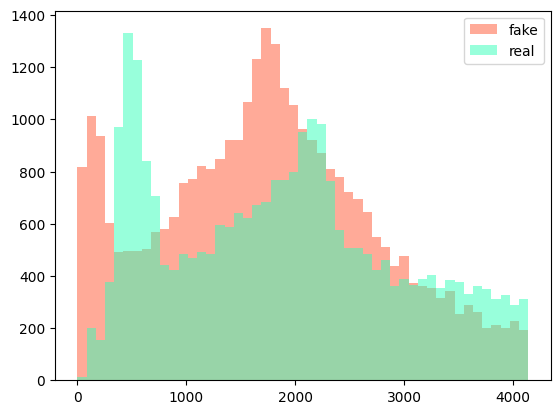

In [62]:
bins = np.linspace(0, 4138, 50)
plt.hist(df[df["label"]== 1]["body_len"], bins, alpha=0.5, label="fake", color="#FF5733")
plt.hist(df[df["label"]== 0]["body_len"], bins, alpha=0.5, label="real", color="#33FFB8")
plt.legend(loc="upper right")
plt.show()

In [63]:
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [64]:
len(stop_words)

198

In [65]:
def clean_text(text):
    text = text.lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)
    text = re.sub(r'\d+', ' ', text)
    words = [w for w in text.split() if w not in stop_words and len(w) > 1]
    return " ".join(words)

df["clean_content"] = df["content"].apply(clean_text)
df[["content", "clean_content"]].head(3)

,content,clean_content
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,law enforcement high alert following threats c...
1,Did they post their votes for Hillary already?,post votes hillary already
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,unbelievable obama’s attorney general says cha...


## Podela na trening i test skupove

In [66]:
X = df["clean_content"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## TF-IDF Vektorizacija

In [67]:
tfidf_vectorizer = TfidfVectorizer(
    max_df=0.9, #reči koje se pojavljuju u više od 90% dokumenata ignorišemo
    min_df=5 #reči koje se pojavljuju manje od 5 puta ignorišemo
)

In [68]:
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [69]:
print("Train:", X_train_tfidf.shape)
print("Test :", X_test_tfidf.shape)

Train: (57707, 57163)
Test : (14427, 57163)


In [70]:
words = tfidf_vectorizer.get_feature_names_out()
print(words[1000:1020])

['agora' 'agorist' 'agosto' 'agrarian' 'agree' 'agreeable' 'agreed'
 'agreeing' 'agreement' 'agreements' 'agrees' 'agri' 'agribusiness'
 'agricultural' 'agriculture' 'agro' 'agrochemical' 'aground' 'ags' 'agua']


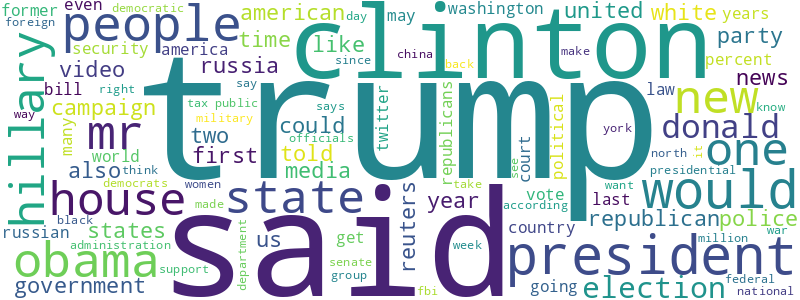

In [72]:
from wordcloud import WordCloud
weights = dict(zip(words, X_train_tfidf.mean(axis=0).tolist()[0]))
wordcloud = WordCloud(width=800, height=300, background_color="white", max_words=100, contour_width=3, contour_color='steelblue').generate_from_frequencies(weights)
wordcloud.to_image()

# 3. Modeli

## 3.1 Multinomial Naive Bayes

In [75]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
y_pred = nb_model.predict(X_test_tfidf)

In [76]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["fake", "real"]))

Accuracy: 0.8678

Classification Report:

              precision    recall  f1-score   support

        fake       0.87      0.86      0.86      7006
        real       0.87      0.88      0.87      7421

    accuracy                           0.87     14427
   macro avg       0.87      0.87      0.87     14427
weighted avg       0.87      0.87      0.87     14427



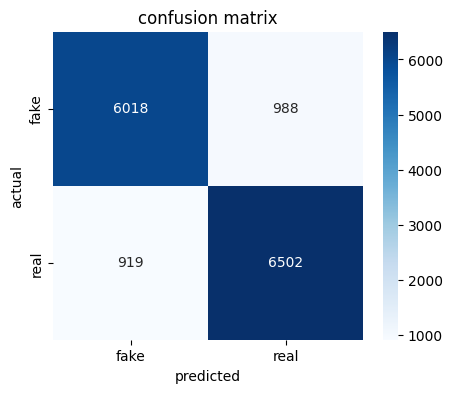

In [77]:
def draw_cm(cm):
  plt.figure(figsize=(5,4))
  sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["fake", "real"], yticklabels=["fake", "real"])
  plt.xlabel("predicted")
  plt.ylabel("actual")
  plt.title("confusion matrix")
  plt.show()

draw_cm(confusion_matrix(y_test, y_pred))

In [78]:
param_grid = {'alpha': [0.01, 0.1, 0.5, 1.0, 10.0]}
grid_search = GridSearchCV(MultinomialNB(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_tfidf, y_train)
print(f"Najbolje alpha: {grid_search.best_params_}")
best_nb_model = grid_search.best_estimator_

Najbolje alpha: {'alpha': 0.01}


In [79]:
y_pred_final = best_nb_model.predict(X_test_tfidf)

In [80]:
acc_nb = accuracy_score(y_test, y_pred_final)
print(f"NB Accuracy: {acc_nb:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_final))

NB Accuracy: 0.8817

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.87      0.88      7006
           1       0.88      0.89      0.89      7421

    accuracy                           0.88     14427
   macro avg       0.88      0.88      0.88     14427
weighted avg       0.88      0.88      0.88     14427



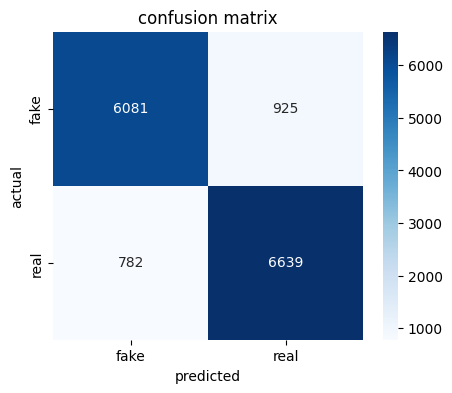

In [81]:
draw_cm(confusion_matrix(y_test, y_pred_final))

## 3.2 Logisticka regresija

In [82]:
param_grid_lr = {'C': [0.1, 1, 10]}
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000), param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1)
grid_lr.fit(X_train_tfidf, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10]}, scoring='accuracy')

In [83]:
print(f"Najbolje C: {grid_lr.best_params_}")
best_lr_model = grid_lr.best_estimator_

Najbolje C: {'C': 10}


In [84]:
y_pred_lr = best_lr_model.predict(X_test_tfidf)
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"LR Accuracy: {acc_lr:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

LR Accuracy: 0.9660

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.96      0.96      7006
           1       0.96      0.97      0.97      7421

    accuracy                           0.97     14427
   macro avg       0.97      0.97      0.97     14427
weighted avg       0.97      0.97      0.97     14427



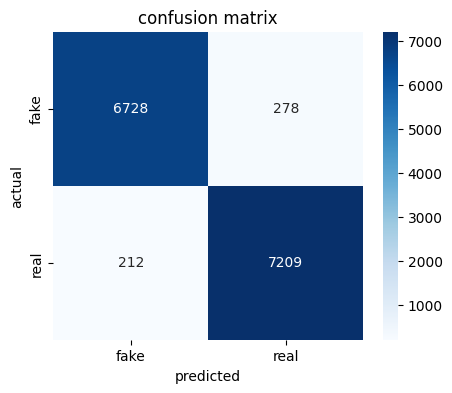

In [86]:
draw_cm(confusion_matrix(y_test, y_pred_lr))

## 3.3 LinearSVC

In [87]:
param_grid_svc = {
    'C': [0.1, 1, 10],
    'dual': [True, False]
}
grid_svc = GridSearchCV(LinearSVC(max_iter=2000), param_grid_svc, cv=3, scoring='accuracy', n_jobs=-1)
grid_svc.fit(X_train_tfidf, y_train)

GridSearchCV(cv=3, estimator=LinearSVC(max_iter=2000), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'dual': [True, False]},
             scoring='accuracy')

In [88]:
print(f"Najbolji parametri: {grid_svc.best_params_}")
best_svc = grid_svc.best_estimator_
y_pred_svc = best_svc.predict(X_test_tfidf)
acc_svc = accuracy_score(y_test, y_pred_svc)
print(f"LinearSVC Accuracy: {acc_svc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_svc))

Najbolji parametri: {'C': 1, 'dual': True}
LinearSVC Accuracy: 0.9681

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.96      0.97      7006
           1       0.96      0.97      0.97      7421

    accuracy                           0.97     14427
   macro avg       0.97      0.97      0.97     14427
weighted avg       0.97      0.97      0.97     14427



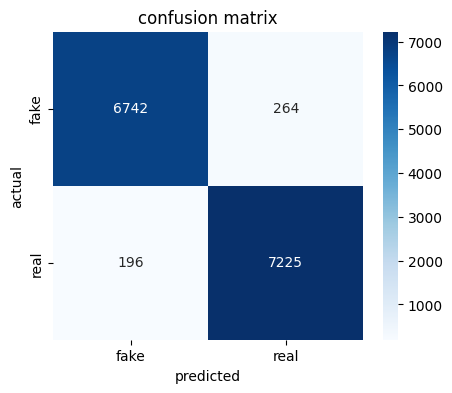

In [89]:
draw_cm(confusion_matrix(y_test, y_pred_svc))

## 3.4 Passive agressive

In [90]:
param_grid_pac = {
    'C': [0.01, 0.1, 1.0, 10.0],
    'max_iter': [50, 100]
}

grid_pac = GridSearchCV(PassiveAggressiveClassifier(random_state=42),
                        param_grid_pac, cv=3, scoring='accuracy', n_jobs=-1)

grid_pac.fit(X_train_tfidf, y_train)

GridSearchCV(cv=3, estimator=PassiveAggressiveClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1.0, 10.0], 'max_iter': [50, 100]},
             scoring='accuracy')

In [91]:
print(f"Najbolji parametri za PAC: {grid_pac.best_params_}")
best_pac = grid_pac.best_estimator_
y_pred_pac = best_pac.predict(X_test_tfidf)
acc_pac = accuracy_score(y_test, y_pred_pac)
print(f"PAC Accuracy: {accuracy_score(y_test, y_pred_pac):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_pac))

Najbolji parametri za PAC: {'C': 0.1, 'max_iter': 50}
PAC Accuracy: 0.9678

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.96      0.97      7006
           1       0.97      0.97      0.97      7421

    accuracy                           0.97     14427
   macro avg       0.97      0.97      0.97     14427
weighted avg       0.97      0.97      0.97     14427



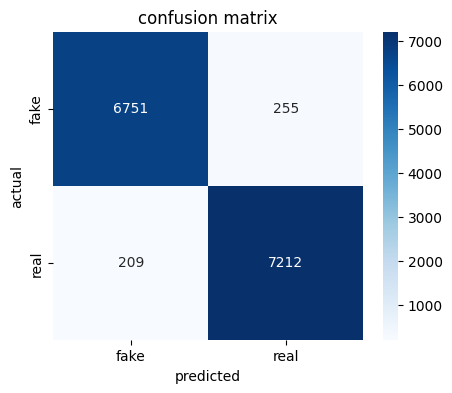

In [92]:
draw_cm(confusion_matrix(y_test, y_pred_pac))

## 3.5 LGBM

In [93]:
lgbm = LGBMClassifier(n_estimators=100, random_state=42)
lgbm.fit(X_train_tfidf.astype('float32'), y_train)
y_pred_lgbm = lgbm.predict(X_test_tfidf.astype('float32'))

[LightGBM] [Info] Number of positive: 29685, number of negative: 28022
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 49.561258 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1884077
[LightGBM] [Info] Number of data points in the train set: 57707, number of used features: 28676
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.514409 -> initscore=0.057652
[LightGBM] [Info] Start training from score 0.057652


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [94]:
acc_lgbm = accuracy_score(y_test, y_pred_lgbm)
print(f"LightGBM Accuracy: {accuracy_score(y_test, y_pred_lgbm):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_lgbm))

LightGBM Accuracy: 0.9691

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.96      0.97      7006
           1       0.96      0.98      0.97      7421

    accuracy                           0.97     14427
   macro avg       0.97      0.97      0.97     14427
weighted avg       0.97      0.97      0.97     14427



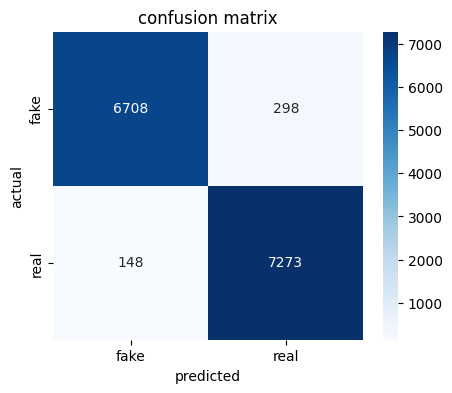

In [95]:
draw_cm(confusion_matrix(y_test, y_pred_lgbm))

## 3.6 LSTM

In [96]:
def prepare_for_lstm(text):
    text = str(text).lower()
    punctuation_pattern = f"[{re.escape(string.punctuation)}]"
    text = re.sub(punctuation_pattern, " ", text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['content_lstm']= df['content'].apply(prepare_for_lstm)

In [97]:
X_train_LSTM, X_test_LSTM, y_train_LSTM, y_test_LSTM = train_test_split(df['content_lstm'], df['label'], test_size=0.2, random_state=42)

In [99]:
max_words = 10000
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train_LSTM)

X_train_seq = tokenizer.texts_to_sequences(X_train_LSTM)
X_test_seq = tokenizer.texts_to_sequences(X_test_LSTM)

max_len = 100
X_train_lstm = pad_sequences(X_train_seq, maxlen=max_len)
X_test_lstm = pad_sequences(X_test_seq, maxlen=max_len)

In [100]:
X_train_lstm.shape

(57707, 100)

In [101]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [102]:
model = Sequential([
    Embedding(max_words, 128),
    SpatialDropout1D(0.3),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(1, activation='sigmoid') # Sigmoid jer imamo 0 ili 1
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [103]:
history = model.fit(X_train_lstm, y_train_LSTM, epochs=10, batch_size=64, validation_split=0.2, callbacks=[early_stop], verbose=1)

Epoch 1/10
722/722 ━━━━━━━━━━━━━━━━━━━━ 168s 224ms/step - accuracy: 0.8604 - loss: 0.3255 - val_accuracy: 0.9375 - val_loss: 0.1728
Epoch 2/10
722/722 ━━━━━━━━━━━━━━━━━━━━ 183s 197ms/step - accuracy: 0.9456 - loss: 0.1496 - val_accuracy: 0.9410 - val_loss: 0.1583
Epoch 3/10
722/722 ━━━━━━━━━━━━━━━━━━━━ 136s 188ms/step - accuracy: 0.9590 - loss: 0.1128 - val_accuracy: 0.9417 - val_loss: 0.1631
Epoch 4/10
722/722 ━━━━━━━━━━━━━━━━━━━━ 136s 189ms/step - accuracy: 0.9726 - loss: 0.0800 - val_accuracy: 0.9460 - val_loss: 0.1697


In [104]:
def draw_lstm_results(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    best_epoch_idx = np.argmin(val_loss)
    best_epoch = best_epoch_idx + 1
    best_val_loss = val_loss[best_epoch_idx]
    best_val_acc = val_acc[best_epoch_idx]

    print(f"REZULTATI NAJBOLJE EPOHE (Epoha {best_epoch}):")
    print(f"LSTM Accuracy: {best_val_acc*100:.2f}%")
    print(f"LSTM Loss: {best_val_loss:.4f}")

    plt.figure(figsize=(15, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b-', alpha=0.5, label='Trening preciznost')
    plt.plot(epochs, val_acc, 'r-', alpha=0.5, label='Validaciona preciznost')
    plt.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.8, label=f'Najbolja epoha ({best_epoch})')
    plt.scatter(best_epoch, best_val_acc, color='green', s=100, edgecolors='black', zorder=5, label='Optimalna tačka')

    plt.title('Preciznost modela kroz epohe', fontsize=14, pad=15)
    plt.xlabel('Epoha', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.xticks(epochs)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', alpha=0.5, label='Trening gubitak')
    plt.plot(epochs, val_loss, 'r-', alpha=0.5, label='Validacioni gubitak')
    plt.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.8, label=f'Najbolja epoha ({best_epoch})')
    plt.scatter(best_epoch, best_val_loss, color='green', s=100, edgecolors='black', zorder=5, label='Minimum gubitka')

    plt.title('Gubitak modela kroz epohe', fontsize=14, pad=15)
    plt.xlabel('Epoha', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.xticks(epochs)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

REZULTATI NAJBOLJE EPOHE (Epoha 2):
LSTM Accuracy: 94.10%
LSTM Loss: 0.1583


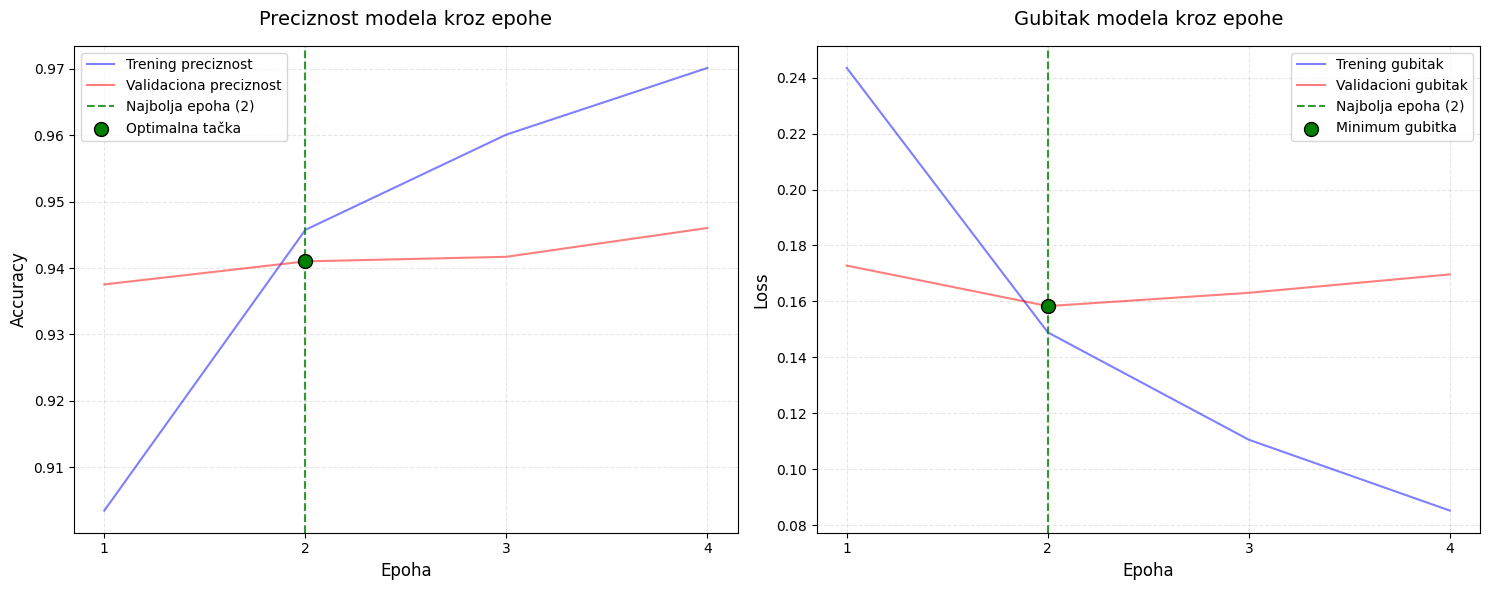

In [105]:
draw_lstm_results(history)

## 3.7 Klasterovanje - KMeans

In [106]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_clusters = kmeans.fit_predict(X_train_tfidf)

In [107]:
df_clusters = pd.DataFrame({'Stvarna_Klasa': y_train, 'Dodoljeni_Klaster': kmeans_clusters})
print("Poklapanje klastera sa stvarnim klasama:")
print(pd.crosstab(df_clusters['Stvarna_Klasa'], df_clusters['Dodoljeni_Klaster']))

Poklapanje klastera sa stvarnim klasama:
Dodoljeni_Klaster      0      1
Stvarna_Klasa                  
0                  20840   7182
1                  19678  10007


In [109]:
from scipy.stats import mode
predicted_clusters = kmeans.labels_
labels = np.zeros_like(predicted_clusters)
for i in range(2):
    mask = (predicted_clusters == i)
    labels[mask] = mode(y_train[mask])[0]
km_acc = accuracy_score(y_train, labels)
print(f"K-Means Accuracy: {km_acc:.4f}")

K-Means Accuracy: 0.5345


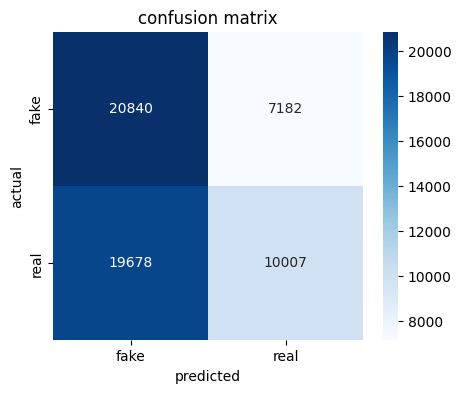

In [111]:
draw_cm(confusion_matrix(y_train, labels))

# 4. Poređenje modela

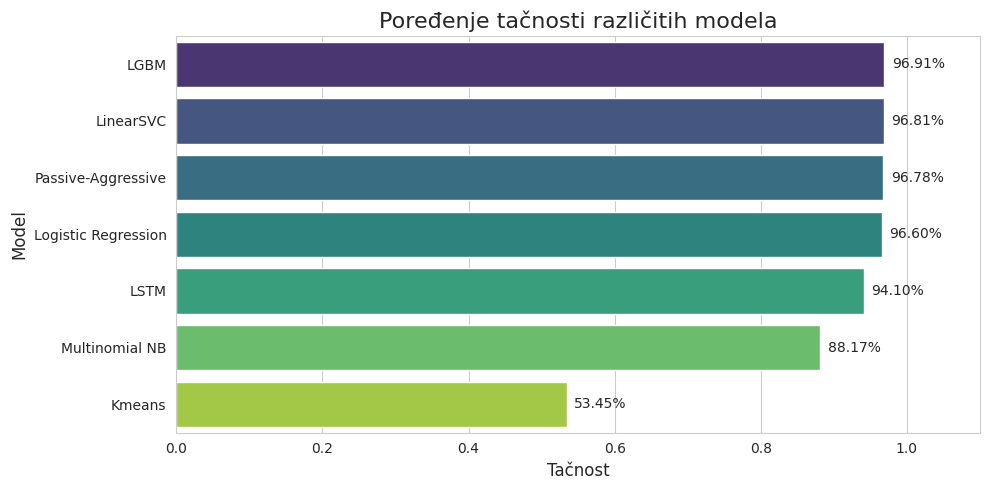

In [116]:
data = {
    'Model': ['Multinomial NB', 'Logistic Regression', 'LinearSVC', 'Passive-Aggressive', 'LGBM', 'LSTM', 'Kmeans'],
    'Accuracy': [acc_nb, acc_lr, acc_svc, acc_pac, acc_lgbm, 0.941, km_acc]
}

results_df = pd.DataFrame(data)
results_df = results_df.sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(10, 5))
sns.set_style("whitegrid")
ax = sns.barplot(x='Accuracy', y='Model', data=results_df, hue='Model',  palette='viridis')

for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.01,
            p.get_y() + p.get_height() / 2,
            f'{width*100:.2f}%',
            ha = 'left',
            va = 'center')

plt.title('Poređenje tačnosti različitih modela', fontsize=16)
plt.xlabel('Tačnost', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.xlim(0, 1.1)
plt.tight_layout()
plt.show()

# 5. Klasifikacija na osnovu naslova

In [117]:
df["title"].apply(len).describe()

,title
count,72134.000000
mean,76.544320
std,25.835571
min,0.000000
25%,61.000000
50%,73.000000
75%,89.000000
max,456.000000


In [118]:
def clean_title(text):
    text = text.lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)
    text = re.sub(r'\d+', ' ', text)
    words = [w for w in text.split() if len(w) > 1]
    return " ".join(words)

df["clean_title"] = df["title"].apply(clean_title)
df[["title", "clean_title"]].head(3)

,title,clean_title
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,law enforcement on high alert following threat...
1,,
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,unbelievable obama’s attorney general says mos...


In [119]:
df_titles = df[df['clean_title'].str.strip() != ""]
df_titles = df_titles[["title", "clean_title", "label"]]
df_titles.head(3)

,title,clean_title,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,law enforcement on high alert following threat...,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,unbelievable obama’s attorney general says mos...,1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",bobby jindal raised hindu uses story of christ...,0


In [22]:
X_title = df_titles["clean_title"]
y_title = df_titles["label"]

X_train_title, X_test_title, y_train_title, y_test_title = train_test_split(
    X_title, y_title, test_size=0.2, random_state=42, stratify=y_title
)

In [120]:
tfidf_v_t = TfidfVectorizer()
tfidf_train_t = tfidf_v_t.fit_transform(X_train_title)
tfidf_test_t = tfidf_v_t.transform(X_test_title)

In [121]:
nb_model_t = MultinomialNB(alpha=0.01)
nb_model_t.fit(tfidf_train_t, y_train_title)
y_pred_nb_t = nb_model_t.predict(tfidf_test_t)

In [122]:
acc_nb_t = accuracy_score(y_test_title, y_pred_nb_t)
print(f"Accuracy: {acc_nb_t:.4f}")

Accuracy: 0.8694


In [123]:
lr_model_t = LogisticRegression(max_iter=1000, C=10)
lr_model_t.fit(tfidf_train_t, y_train_title)
y_pred_lr_t = lr_model_t.predict(tfidf_test_t)

In [124]:
acc_lr_t = accuracy_score(y_test_title, y_pred_lr_t)
print(f"Accuracy: {acc_lr_t:.4f}")

Accuracy: 0.9136


In [125]:
svc_model_t = LinearSVC(max_iter=200, C=1, dual=True)
svc_model_t.fit(tfidf_train_t, y_train_title)
y_pred_svc_t = svc_model_t.predict(tfidf_test_t)

In [126]:
acc_svc_t = accuracy_score(y_test_title, y_pred_svc_t)
print(f"Accuracy: {acc_svc_t:.4f}")

Accuracy: 0.9151


In [127]:
pa_model_t = PassiveAggressiveClassifier(random_state=42, C=0.1)
pa_model_t.fit(tfidf_train_t, y_train_title)
y_pred_pa_t = pa_model_t.predict(tfidf_test_t)

In [128]:
acc_pa_t = accuracy_score(y_test_title, y_pred_pa_t)
print(f"Accuracy: {acc_pa_t:.4f}")

Accuracy: 0.9095


In [132]:
comparison_data = {
    'Model': [
        'Multinomial NB',
        'Logistička Regresija',
        'LinearSVC',
        'Passive-Aggressive'
    ],
    'Tačnost (ceo tekst)': [
        acc_nb, acc_lr, acc_svc, acc_pac
    ],
    'Tačnost (samo naslov)': [
        acc_nb_t, acc_lr_t, acc_svc_t, acc_pa_t
    ]
}

df_comp = pd.DataFrame(comparison_data)
df_comp['Razlika (%)'] = (df_comp['Tačnost (ceo tekst)'] - df_comp['Tačnost (samo naslov)']) * 100

print("UPOREDNA TABELA: TEKST VS. NASLOV")
display(df_comp)

UPOREDNA TABELA: TEKST VS. NASLOV


,Model,Tačnost (ceo tekst),Tačnost (samo naslov),Razlika (%)
0,Multinomial NB,0.881680,0.869368,1.231239
1,Logistička Regresija,0.966036,0.913587,5.244876
2,LinearSVC,0.968115,0.915124,5.299134
3,Passive-Aggressive,0.967838,0.909466,5.837249


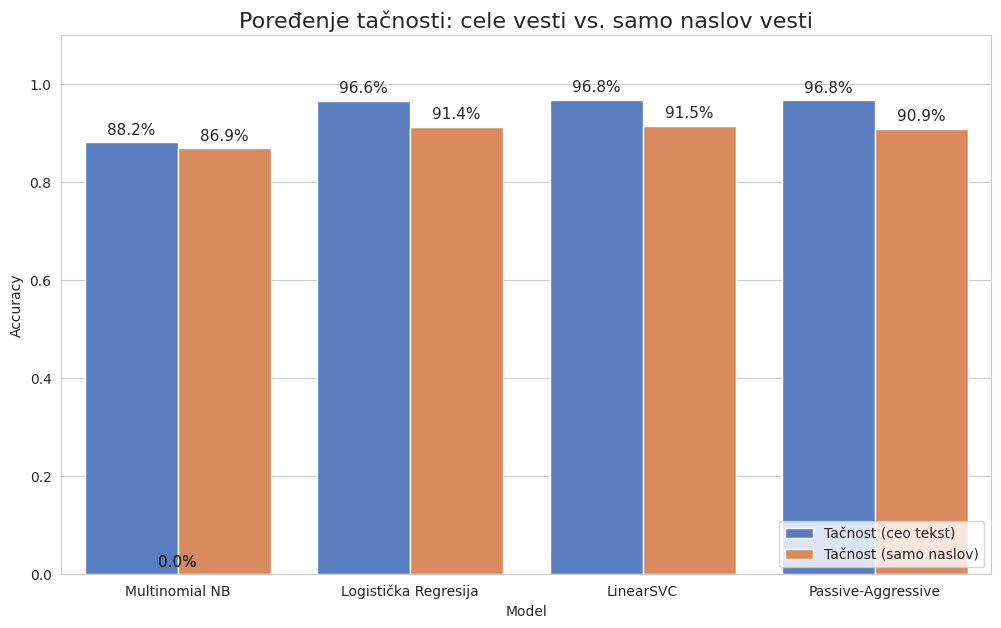

In [133]:
df_plot = df_comp.melt(id_vars='Model', value_vars=['Tačnost (ceo tekst)', 'Tačnost (samo naslov)'],
                       var_name='Tip analize', value_name='Tačnost')
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
ax = sns.barplot(x='Model', y='Tačnost', hue='Tip analize', data=df_plot, palette='muted')
for p in ax.patches:
    ax.annotate(f'{p.get_height()*100:.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=11)

plt.title('Poređenje tačnosti: cele vesti vs. samo naslov vesti', fontsize=16)
plt.ylim(0, 1.1)
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()